In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, log_loss, roc_auc_score, 
                            confusion_matrix, roc_curve, classification_report)

from myXGBoost.estimators.classifier import XGBClassifier as MyXGBClf

In [2]:
# Generate synthetic binary classification data
X, y = make_classification(
    n_samples=2000, 
    n_features=20, 
    n_informative=8,
    n_redundant=2,
    n_repeated=0,
    n_clusters_per_class=1,
    random_state=42
)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Classification Dataset Statistics:")
print("=" * 50)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"\nClass distribution (training):")
print(f"  Class 0: {np.sum(y_train == 0)} samples ({np.mean(y_train == 0) * 100:.1f}%)")
print(f"  Class 1: {np.sum(y_train == 1)} samples ({np.mean(y_train == 1) * 100:.1f}%)")
print(f"\nClass distribution (testing):")
print(f"  Class 0: {np.sum(y_test == 0)} samples ({np.mean(y_test == 0) * 100:.1f}%)")
print(f"  Class 1: {np.sum(y_test == 1)} samples ({np.mean(y_test == 1) * 100:.1f}%)")
print(f"\nNumber of informative features: 8")
print(f"Number of redundant features:   2")

Classification Dataset Statistics:
X_train shape: (1600, 20)
X_test shape:  (400, 20)
y_train shape: (1600,)
y_test shape:  (400,)

Class distribution (training):
  Class 0: 799 samples (49.9%)
  Class 1: 801 samples (50.1%)

Class distribution (testing):
  Class 0: 200 samples (50.0%)
  Class 1: 200 samples (50.0%)

Number of informative features: 8
Number of redundant features:   2


In [3]:
# Create and train myXGBoost classifier
clf = MyXGBClf(n_estimators=100, random_state=42)

t0 = time.time()
clf.fit(X_train, y_train)
t1 = time.time()
training_time = t1 - t0

# Make predictions
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)

# For binary classification, get probability of positive class
if y_proba.ndim > 1:
    y_pos_proba = y_proba[:, 1]
else:
    y_pos_proba = y_proba

print(f"myXGBoost Classifier Training Complete!")
print("-" * 40)
print(f"Training time: {training_time:.4f} seconds")
print(f"Number of estimators: {clf.n_estimators}")
print(f"\nPredictions generated:")
print(f"  • Class predictions shape: {y_pred.shape}")
print(f"  • Probability predictions shape: {y_proba.shape}")

myXGBoost Classifier Training Complete!
----------------------------------------
Training time: 2.8050 seconds
Number of estimators: 100

Predictions generated:
  • Class predictions shape: (400,)
  • Probability predictions shape: (400, 2)


In [4]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
logloss = log_loss(y_test, y_pos_proba)
auc = roc_auc_score(y_test, y_pos_proba)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Calculate additional metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print("myXGBoost Classification Results:")
print("=" * 60)
print(f"Primary Metrics:")
print(f"  • Accuracy:  {accuracy:.4f}")
print(f"  • Log Loss:  {logloss:.4f}")
print(f"  • AUC-ROC:   {auc:.4f}")
print(f"  • F1 Score:  {f1_score:.4f}")
print(f"\nDetailed Metrics:")
print(f"  • Precision: {precision:.4f}")
print(f"  • Recall:    {recall:.4f}")
print(f"  • Specificity: {specificity:.4f}")
print(f"\nConfusion Matrix:")
print(f"  [[{tn:4d}  {fp:4d}]  -> True Neg: {tn}, False Pos: {fp}")
print(f"   [{fn:4d}  {tp:4d}]]  -> False Neg: {fn}, True Pos: {tp}")
print("=" * 60)

# Compare with baseline (majority class)
baseline_accuracy = max(np.mean(y_test == 0), np.mean(y_test == 1))
print(f"\nBaseline (majority class): Accuracy = {baseline_accuracy:.4f}")
print(f"Improvement over baseline: {accuracy - baseline_accuracy:.4f} (+{(accuracy - baseline_accuracy) / baseline_accuracy * 100:.2f}%)")

myXGBoost Classification Results:
Primary Metrics:
  • Accuracy:  0.9750
  • Log Loss:  0.1012
  • AUC-ROC:   0.9901
  • F1 Score:  0.9750

Detailed Metrics:
  • Precision: 0.9750
  • Recall:    0.9750
  • Specificity: 0.9750

Confusion Matrix:
  [[ 195     5]  -> True Neg: 195, False Pos: 5
   [   5   195]]  -> False Neg: 5, True Pos: 195

Baseline (majority class): Accuracy = 0.5000
Improvement over baseline: 0.4750 (+95.00%)


In [5]:
# Generate detailed classification report
print("Classification Report:")
print("-" * 60)
report = classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1'])
print(report)

# Print probability statistics
print("\nPrediction Probability Statistics:")
print("-" * 40)
print(f"Mean probability for Class 1: {y_pos_proba.mean():.4f}")
print(f"Std of probabilities:         {y_pos_proba.std():.4f}")
print(f"Min probability:              {y_pos_proba.min():.4f}")
print(f"Max probability:              {y_pos_proba.max():.4f}")
print(f"\nConfidence in predictions:")
print(f"High confidence (>0.8):       {np.mean(y_pos_proba > 0.8) * 100:.1f}%")
print(f"Medium confidence (0.6-0.8):  {np.mean((y_pos_proba >= 0.6) & (y_pos_proba <= 0.8)) * 100:.1f}%")
print(f"Low confidence (0.4-0.6):     {np.mean((y_pos_proba >= 0.4) & (y_pos_proba <= 0.6)) * 100:.1f}%")
print(f"Uncertain (<0.4):             {np.mean(y_pos_proba < 0.4) * 100:.1f}%")

Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

     Class 0       0.97      0.97      0.97       200
     Class 1       0.97      0.97      0.97       200

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400


Prediction Probability Statistics:
----------------------------------------
Mean probability for Class 1: 0.4996
Std of probabilities:         0.4792
Min probability:              0.0004
Max probability:              0.9995

Confidence in predictions:
High confidence (>0.8):       47.8%
Medium confidence (0.6-0.8):  1.0%
Low confidence (0.4-0.6):     2.0%
Uncertain (<0.4):             49.2%


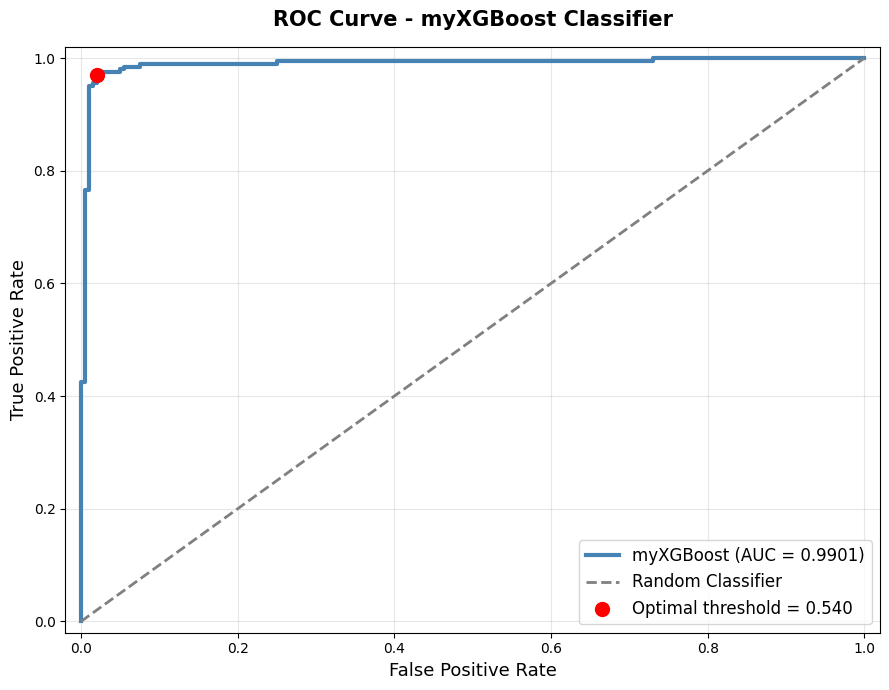

Optimal threshold (Youden's J): 0.5402
At this threshold:
  • True Positive Rate: 0.9700
  • False Positive Rate: 0.0200
  • Youden's J (TPR - FPR): 0.9500


In [6]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pos_proba)

# Calculate optimal threshold (Youden's J statistic)
youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]

# Create ROC curve plot
plt.figure(figsize=(9, 7))
plt.plot(fpr, tpr, linewidth=3, label=f'myXGBoost (AUC = {auc:.4f})', color='steelblue')
plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=2, label='Random Classifier')

# Mark optimal threshold point
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100, 
           label=f'Optimal threshold = {optimal_threshold:.3f}', zorder=5)

# Format plot
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve - myXGBoost Classifier', fontsize=15, pad=15, fontweight='bold')
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, alpha=0.3)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.tight_layout()
plt.show()

print(f"Optimal threshold (Youden's J): {optimal_threshold:.4f}")
print(f"At this threshold:")
print(f"  • True Positive Rate: {tpr[optimal_idx]:.4f}")
print(f"  • False Positive Rate: {fpr[optimal_idx]:.4f}")
print(f"  • Youden's J (TPR - FPR): {youden_j[optimal_idx]:.4f}")

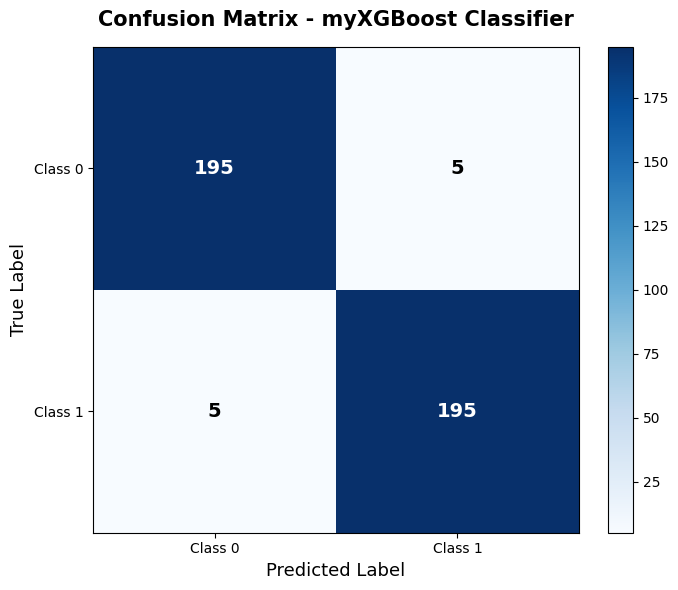

Confusion Matrix (Percentages):
True Class 0 predicted as Class 0: 97.5% (195 samples)
True Class 0 predicted as Class 1: 2.5% (5 samples)
True Class 1 predicted as Class 0: 2.5% (5 samples)
True Class 1 predicted as Class 1: 97.5% (195 samples)


In [7]:
# Create confusion matrix visualization
plt.figure(figsize=(8, 6))

# Create heatmap
im = plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, fraction=0.046, pad=0.04)

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=14, fontweight='bold')

# Format plot
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)
plt.title('Confusion Matrix - myXGBoost Classifier', fontsize=15, pad=15, fontweight='bold')
plt.xticks([0, 1], ['Class 0', 'Class 1'])
plt.yticks([0, 1], ['Class 0', 'Class 1'])
plt.tight_layout()
plt.show()

# Calculate percentages for confusion matrix
cm_percent = cm / cm.sum(axis=1)[:, np.newaxis] * 100

print("Confusion Matrix (Percentages):")
print(f"True Class 0 predicted as Class 0: {cm_percent[0, 0]:.1f}% ({cm[0, 0]} samples)")
print(f"True Class 0 predicted as Class 1: {cm_percent[0, 1]:.1f}% ({cm[0, 1]} samples)")
print(f"True Class 1 predicted as Class 0: {cm_percent[1, 0]:.1f}% ({cm[1, 0]} samples)")
print(f"True Class 1 predicted as Class 1: {cm_percent[1, 1]:.1f}% ({cm[1, 1]} samples)")

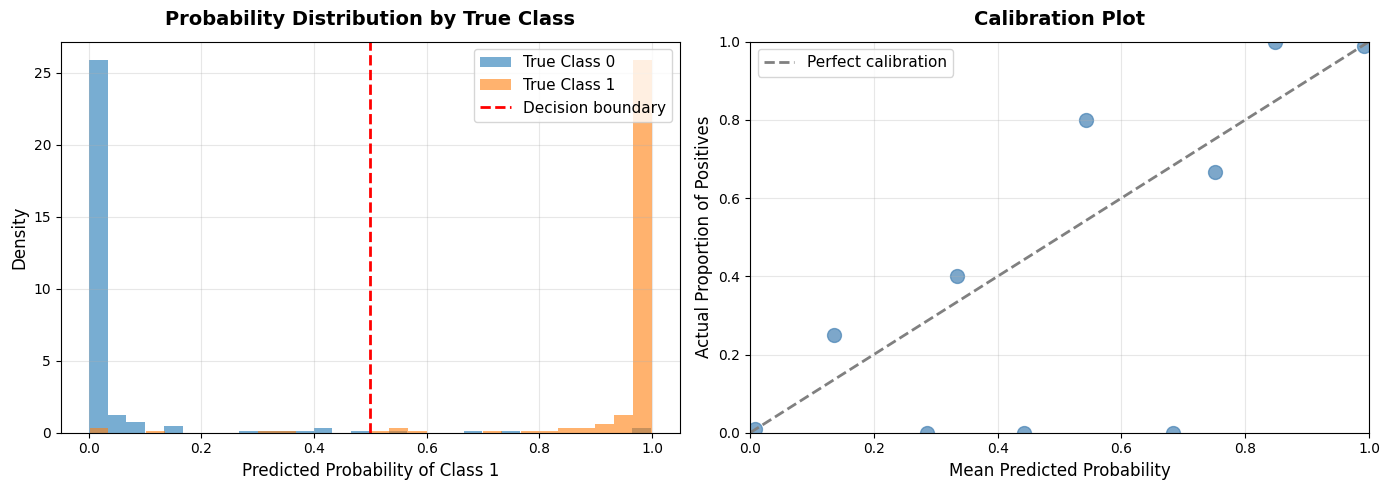

Calibration Analysis:
----------------------------------------
Mean absolute calibration error: 0.2091
⚠ Calibration could be improved


In [8]:
# Create probability distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Probability distribution by true class
for class_label in [0, 1]:
    mask = y_test == class_label
    axes[0].hist(y_pos_proba[mask], bins=30, alpha=0.6, 
                label=f'True Class {class_label}', density=True)

axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision boundary')
axes[0].set_xlabel('Predicted Probability of Class 1', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Probability Distribution by True Class', fontsize=14, pad=12, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 2. Calibration plot
bins = np.linspace(0, 1, 11)
bin_centers = (bins[:-1] + bins[1:]) / 2
actual_proportions = []
predicted_proportions = []

for i in range(len(bins) - 1):
    mask = (y_pos_proba >= bins[i]) & (y_pos_proba < bins[i+1])
    if np.sum(mask) > 0:
        actual_prop = np.mean(y_test[mask] == 1)
        predicted_prop = np.mean(y_pos_proba[mask])
        actual_proportions.append(actual_prop)
        predicted_proportions.append(predicted_prop)

axes[1].scatter(predicted_proportions, actual_proportions, s=100, alpha=0.7, color='steelblue')
axes[1].plot([0, 1], [0, 1], '--', color='gray', linewidth=2, label='Perfect calibration')
axes[1].set_xlabel('Mean Predicted Probability', fontsize=12)
axes[1].set_ylabel('Actual Proportion of Positives', fontsize=12)
axes[1].set_title('Calibration Plot', fontsize=14, pad=12, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Calculate calibration metrics
print("Calibration Analysis:")
print("-" * 40)
miscalibration = np.abs(np.array(actual_proportions) - np.array(predicted_proportions)).mean()
print(f"Mean absolute calibration error: {miscalibration:.4f}")
if miscalibration < 0.05:
    print("✓ Excellent calibration")
elif miscalibration < 0.1:
    print("✓ Good calibration")
else:
    print("⚠ Calibration could be improved")

In [9]:
# Check if feature_importances_ attribute exists
if hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
    
    if importances is not None and len(importances) > 0:
        plt.figure(figsize=(12, 7))
        
        # Sort importances
        indices = np.argsort(importances)[::-1]
        sorted_importances = importances[indices]
        feature_names = [f'Feature {i+1}' for i in range(len(importances))]
        sorted_features = [feature_names[i] for i in indices]
        
        # Create horizontal bar chart
        bars = plt.barh(range(len(importances)), sorted_importances, 
                       align='center', color='steelblue', alpha=0.8)
        
        # Add value labels
        for i, (bar, val) in enumerate(zip(bars, sorted_importances)):
            width = bar.get_width()
            plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
                    f'{val:.4f}', va='center', fontsize=9)
        
        plt.yticks(range(len(importances)), sorted_features, fontsize=11)
        plt.xlabel('Feature Importance', fontsize=13)
        plt.ylabel('Features', fontsize=13)
        plt.title('myXGBoost Classifier: Feature Importances', fontsize=15, pad=15, fontweight='bold')
        plt.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()
        
        # Print top features
        print("Top 10 Most Important Features for Classification:")
        print("-" * 50)
        total_importance = sum(sorted_importances)
        for i in range(min(10, len(sorted_features))):
            importance_pct = sorted_importances[i] / total_importance * 100
            print(f"{i+1:2d}. {sorted_features[i]:15} "
                  f"{sorted_importances[i]:.6f} ({importance_pct:5.1f}%)")
        
        # Check which informative features were identified
        informative_features = list(range(8))  # First 8 are informative
        important_indices = indices[:10]
        informative_found = sum(1 for idx in important_indices if idx < 8)
        print(f"\nInformative features in top 10: {informative_found}/8")
        
    else:
        print("Feature importances are None or empty.")
else:
    print("Feature importances attribute not found in the classifier.")

Feature importances attribute not found in the classifier.


In [10]:
# Check if staged_predict_proba method exists
if hasattr(clf, 'staged_predict_proba'):
    try:
        # Get predictions at each stage
        staged_preds = list(clf.staged_predict_proba(X_test))
        
        # Calculate metrics at each stage
        accuracy_scores = []
        logloss_scores = []
        
        for i, proba in enumerate(staged_preds):
            if proba.ndim > 1:
                stage_proba = proba[:, 1]
                stage_pred = (stage_proba >= 0.5).astype(int)
            else:
                stage_proba = proba
                stage_pred = (stage_proba >= 0.5).astype(int)
            
            accuracy_scores.append(accuracy_score(y_test, stage_pred))
            logloss_scores.append(log_loss(y_test, stage_proba))
        
        # Create figure with subplots
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # 1. Accuracy over iterations
        axes[0].plot(range(1, len(accuracy_scores) + 1), accuracy_scores, 
                    marker='o', markersize=3, linewidth=1.5, color='green')
        axes[0].set_xlabel('Number of Estimators', fontsize=12)
        axes[0].set_ylabel('Accuracy', fontsize=12)
        axes[0].set_title('Accuracy vs Number of Estimators', fontsize=14, pad=12, fontweight='bold')
        axes[0].grid(True, alpha=0.3)
        axes[0].set_ylim([0.5, 1.0])
        
        # Add best iteration marker
        best_acc_iter = np.argmax(accuracy_scores)
        axes[0].scatter(best_acc_iter + 1, accuracy_scores[best_acc_iter], 
                       color='red', s=100, zorder=5, label=f'Best: iter {best_acc_iter + 1}')
        axes[0].legend()
        
        # 2. Log Loss over iterations
        axes[1].plot(range(1, len(logloss_scores) + 1), logloss_scores, 
                    marker='s', markersize=3, linewidth=1.5, color='red')
        axes[1].set_xlabel('Number of Estimators', fontsize=12)
        axes[1].set_ylabel('Log Loss', fontsize=12)
        axes[1].set_title('Log Loss vs Number of Estimators', fontsize=14, pad=12, fontweight='bold')
        axes[1].grid(True, alpha=0.3)
        
        # Add best iteration marker
        best_logloss_iter = np.argmin(logloss_scores)
        axes[1].scatter(best_logloss_iter + 1, logloss_scores[best_logloss_iter], 
                       color='red', s=100, zorder=5, label=f'Best: iter {best_logloss_iter + 1}')
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()
        
        # Print learning progress summary
        print("Learning Progress Summary:")
        print("-" * 40)
        print(f"Best Accuracy:  {accuracy_scores[best_acc_iter]:.4f} at iteration {best_acc_iter + 1}")
        print(f"Best Log Loss:  {logloss_scores[best_logloss_iter]:.4f} at iteration {best_logloss_iter + 1}")
        print(f"Final Accuracy: {accuracy_scores[-1]:.4f}")
        print(f"Final Log Loss: {logloss_scores[-1]:.4f}")
        
    except Exception as e:
        print(f"Could not generate learning curve: {e}")
else:
    print("staged_predict_proba method not available for learning curve visualization.")

staged_predict_proba method not available for learning curve visualization.


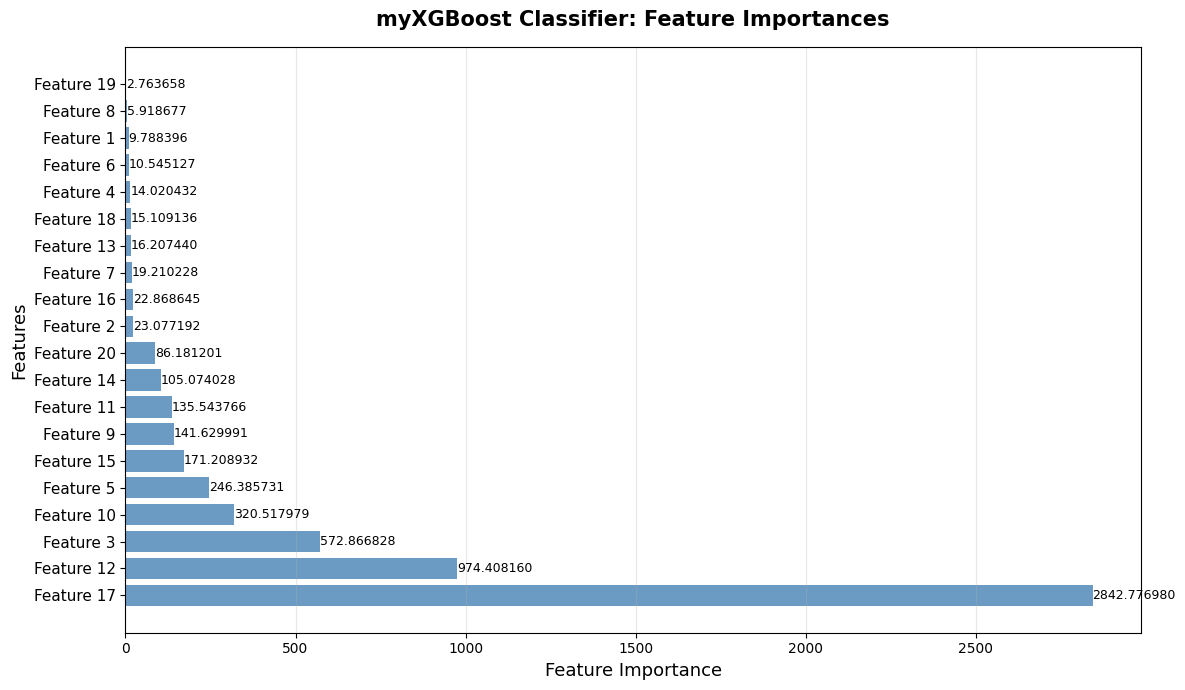

Top 10 Most Important Features for Classification:
--------------------------------------------------
 1. Feature 17      2842.776980 ( 49.6%)
 2. Feature 12      974.408160 ( 17.0%)
 3. Feature 3       572.866828 ( 10.0%)
 4. Feature 10      320.517979 (  5.6%)
 5. Feature 5       246.385731 (  4.3%)
 6. Feature 15      171.208932 (  3.0%)
 7. Feature 9       141.629991 (  2.5%)
 8. Feature 11      135.543766 (  2.4%)
 9. Feature 14      105.074028 (  1.8%)
10. Feature 20      86.181201 (  1.5%)

Informative features in top 10: 2/8


In [12]:
# Obtain feature importances: prefer sklearn-style attribute, fallback to
# myXGBoost's booster-based computation when available.
import math
importances = None
if hasattr(clf, 'feature_importances_'):
    try:
        importances = np.asarray(clf.feature_importances_)
    except Exception:
        importances = None

if importances is None and hasattr(clf, 'booster_'):
    try:
        from myXGBoost.utils.visualization import compute_feature_importance
        imp_dict = compute_feature_importance(clf.booster_, importance_type='gain')
        # convert dict to array
        if imp_dict:
            n_feats = max(imp_dict.keys()) + 1
            importances = np.zeros(n_feats, dtype=float)
            for k, v in imp_dict.items():
                importances[k] = v
    except Exception as e:
        importances = None

if importances is not None and importances.size > 0 and not np.all(np.isnan(importances)):
    plt.figure(figsize=(12, 7))
    indices = np.argsort(importances)[::-1]
    sorted_importances = importances[indices]
    feature_names = [f'Feature {i+1}' for i in range(importances.size)]
    sorted_features = [feature_names[i] for i in indices]

    bars = plt.barh(range(len(importances)), sorted_importances, align='center', color='steelblue', alpha=0.8)
    for i, (bar, val) in enumerate(zip(bars, sorted_importances)):
        width = bar.get_width()
        plt.text(width + (0.01 if width >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
                 f'{val:.6f}', va='center', fontsize=9)

    plt.yticks(range(len(importances)), sorted_features, fontsize=11)
    plt.xlabel('Feature Importance', fontsize=13)
    plt.ylabel('Features', fontsize=13)
    plt.title('myXGBoost Classifier: Feature Importances', fontsize=15, pad=15, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

    # Print top features
    print("Top 10 Most Important Features for Classification:")
    print("-" * 50)
    total_importance = float(np.sum(sorted_importances)) if not math.isclose(np.sum(sorted_importances), 0.0) else 1.0
    for i in range(min(10, len(sorted_features))):
        importance_pct = (sorted_importances[i] / total_importance) * 100
        print(f"{i+1:2d}. {sorted_features[i]:15} {sorted_importances[i]:.6f} ({importance_pct:5.1f}%)")

    # If the dataset had known informative features (e.g., first 8), report overlap
    try:
        informative_features = list(range(8))  # First 8 are informative in synthetic data
        important_indices = indices[:10]
        informative_found = sum(1 for idx in important_indices if idx < 8)
        print(f"\nInformative features in top 10: {informative_found}/8")
    except Exception:
        pass
else:
    print("Feature importances not available for this classifier.")




staged_predict_proba method not available for learning curve visualization.


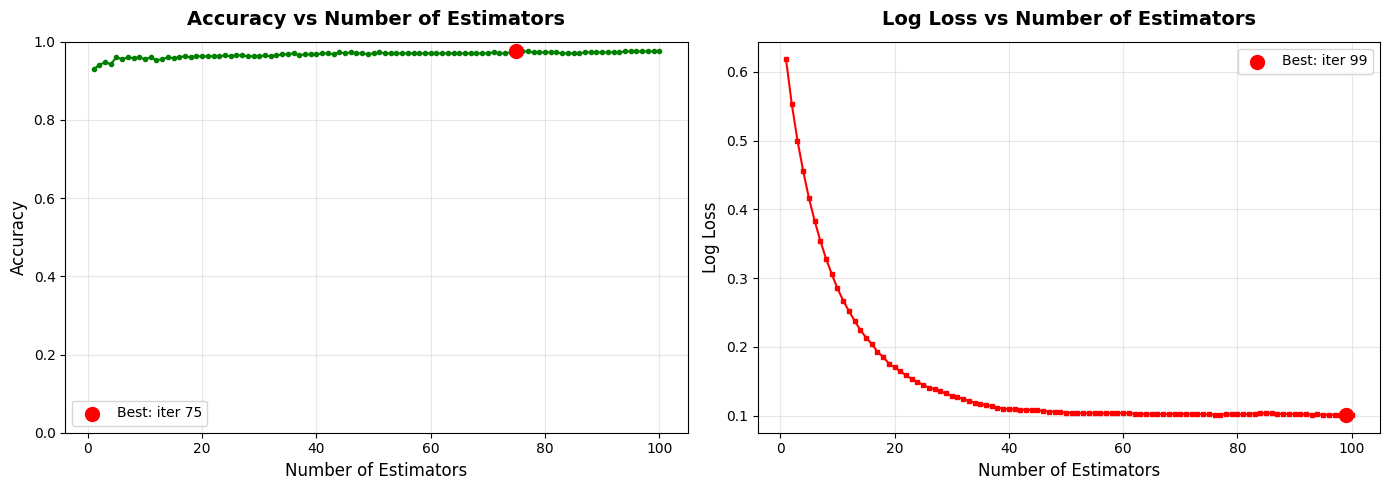

Learning Progress Summary:
----------------------------------------
Best Accuracy:  0.9750 at iteration 75
Best Log Loss:  0.1010 at iteration 99
Final Accuracy: 0.9750
Final Log Loss: 0.1012


In [14]:
# Check if staged_predict_proba method exists
if hasattr(clf, 'staged_predict_proba'):
    try:
        # Get predictions at each stage
        staged_preds = list(clf.staged_predict_proba(X_test))
        
        # Calculate metrics at each stage
        accuracy_scores = []
        logloss_scores = []
        
        for i, proba in enumerate(staged_preds):
            if proba.ndim > 1:
                stage_proba = proba[:, 1]
                stage_pred = (stage_proba >= 0.5).astype(int)
            else:
                stage_proba = proba
                stage_pred = (stage_proba >= 0.5).astype(int)
            
            accuracy_scores.append(accuracy_score(y_test, stage_pred))
            logloss_scores.append(log_loss(y_test, stage_proba))
        
        # Create figure with subplots
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # 1. Accuracy over iterations
        axes[0].plot(range(1, len(accuracy_scores) + 1), accuracy_scores, 
                    marker='o', markersize=3, linewidth=1.5, color='green')
        axes[0].set_xlabel('Number of Estimators', fontsize=12)
        axes[0].set_ylabel('Accuracy', fontsize=12)
        axes[0].set_title('Accuracy vs Number of Estimators', fontsize=14, pad=12, fontweight='bold')
        axes[0].grid(True, alpha=0.3)
        axes[0].set_ylim([0.5, 1.0])
        
        # Add best iteration marker
        best_acc_iter = np.argmax(accuracy_scores)
        axes[0].scatter(best_acc_iter + 1, accuracy_scores[best_acc_iter], 
                       color='red', s=100, zorder=5, label=f'Best: iter {best_acc_iter + 1}')
        axes[0].legend()
        
        # 2. Log Loss over iterations
        axes[1].plot(range(1, len(logloss_scores) + 1), logloss_scores, 
                    marker='s', markersize=3, linewidth=1.5, color='red')
        axes[1].set_xlabel('Number of Estimators', fontsize=12)
        axes[1].set_ylabel('Log Loss', fontsize=12)
        axes[1].set_title('Log Loss vs Number of Estimators', fontsize=14, pad=12, fontweight='bold')
        axes[1].grid(True, alpha=0.3)
        
        # Add best iteration marker
        best_logloss_iter = np.argmin(logloss_scores)
        axes[1].scatter(best_logloss_iter + 1, logloss_scores[best_logloss_iter], 
                       color='red', s=100, zorder=5, label=f'Best: iter {best_logloss_iter + 1}')
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()
        
        # Print learning progress summary
        print("Learning Progress Summary:")
        print("-" * 40)
        print(f"Best Accuracy:  {accuracy_scores[best_acc_iter]:.4f} at iteration {best_acc_iter + 1}")
        print(f"Best Log Loss:  {logloss_scores[best_logloss_iter]:.4f} at iteration {best_logloss_iter + 1}")
        print(f"Final Accuracy: {accuracy_scores[-1]:.4f}")
        print(f"Final Log Loss: {logloss_scores[-1]:.4f}")
        
    except Exception as e:
        print(f"Could not generate learning curve: {e}")
else:
    print("staged_predict_proba method not available for learning curve visualization.")
if hasattr(clf, 'staged_predict_proba'):
    try:
        staged_preds = list(clf.staged_predict_proba(X_test))
    except Exception:
        staged_preds = None
else:
    staged_preds = None

if staged_preds is None and hasattr(clf, 'booster_'):
    try:
        booster = clf.booster_
        n_trees = len(getattr(booster, 'trees', []))
        staged_preds = []
        for k in range(1, n_trees + 1):
            raw = np.full(X_test.shape[0], getattr(booster, 'initial_prediction', 0.0), dtype=float)
            for i in range(k):
                raw += booster.learning_rate * booster.trees[i].predict(X_test)
            from myXGBoost.loss.classification import sigmoid
            proba_pos = sigmoid(raw)
            staged_preds.append(np.column_stack([1 - proba_pos, proba_pos]))
    except Exception:
        staged_preds = None

if staged_preds:
    try:
        accuracy_scores = []
        logloss_scores = []
        for proba in staged_preds:
            if proba.ndim > 1:
                stage_proba = proba[:, 1]
                stage_pred = (stage_proba >= 0.5).astype(int)
            else:
                stage_proba = proba
                stage_pred = (stage_proba >= 0.5).astype(int)
            accuracy_scores.append(accuracy_score(y_test, stage_pred))
            logloss_scores.append(log_loss(y_test, stage_proba))

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].plot(range(1, len(accuracy_scores) + 1), accuracy_scores, marker='o', markersize=3, linewidth=1.5, color='green')
        axes[0].set_xlabel('Number of Estimators', fontsize=12)
        axes[0].set_ylabel('Accuracy', fontsize=12)
        axes[0].set_title('Accuracy vs Number of Estimators', fontsize=14, pad=12, fontweight='bold')
        axes[0].grid(True, alpha=0.3)
        axes[0].set_ylim([0.0, 1.0])

        best_acc_iter = int(np.argmax(accuracy_scores))
        axes[0].scatter(best_acc_iter + 1, accuracy_scores[best_acc_iter], color='red', s=100, zorder=5, label=f'Best: iter {best_acc_iter + 1}')
        axes[0].legend()

        axes[1].plot(range(1, len(logloss_scores) + 1), logloss_scores, marker='s', markersize=3, linewidth=1.5, color='red')
        axes[1].set_xlabel('Number of Estimators', fontsize=12)
        axes[1].set_ylabel('Log Loss', fontsize=12)
        axes[1].set_title('Log Loss vs Number of Estimators', fontsize=14, pad=12, fontweight='bold')
        axes[1].grid(True, alpha=0.3)

        best_logloss_iter = int(np.argmin(logloss_scores))
        axes[1].scatter(best_logloss_iter + 1, logloss_scores[best_logloss_iter], color='red', s=100, zorder=5, label=f'Best: iter {best_logloss_iter + 1}')
        axes[1].legend()

        plt.tight_layout(); plt.show()

        print('Learning Progress Summary:')
        print('-' * 40)
        print(f"Best Accuracy:  {accuracy_scores[best_acc_iter]:.4f} at iteration {best_acc_iter + 1}")
        print(f"Best Log Loss:  {logloss_scores[best_logloss_iter]:.4f} at iteration {best_logloss_iter + 1}")
        print(f"Final Accuracy: {accuracy_scores[-1]:.4f}")
        print(f"Final Log Loss: {logloss_scores[-1]:.4f}")
    except Exception as e:
        print(f"Could not generate learning curve: {e}")
else:
    print("staged_predict_proba method not available and booster-based fallback failed.")